# EXP_001 — Exploratory Data Analysis
Understand the dataset structure, audio characteristics, and train/test distribution shift.

## Setup

In [14]:
import os, glob, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from collections import Counter
from dataclasses import dataclass, field
from typing import List
import librosa, librosa.display

warnings.filterwarnings('ignore')
SEED = 42; random.seed(SEED); np.random.seed(SEED)

@dataclass
class Config:
    data_root: str = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
    output_dir: str = '/kaggle/working'
    sr: int = 22050
    duration: float = 10.0
    n_mels: int = 128
    n_fft: int = 2048
    hop_length: int = 512
    fmin: int = 20
    fmax: int = 11025
    genres: List[str] = field(default_factory=lambda: sorted([
        'blues','classical','country','disco','hiphop',
        'jazz','metal','pop','reggae','rock']))
    stem_types: List[str] = field(default_factory=lambda: ['drums','vocals','bass','others'])
    entity: str = "23f3003225-indian-institute-of-technology-madras"
    project: str = "23f3003225-dl-genai-project"
    @property
    def stems_dir(self): return os.path.join(self.data_root, 'genres_stems')
    @property
    def noise_dir(self): return os.path.join(self.data_root, 'ESC-50-master', 'audio')
    @property
    def noise_meta(self): return os.path.join(self.data_root, 'ESC-50-master', 'meta', 'esc50.csv')
    @property
    def test_dir(self): return os.path.join(self.data_root, 'mashups')
    @property
    def test_csv(self): return os.path.join(self.data_root, 'test.csv')

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)

def load_audio(path, sr=22050, duration=None):
    try:
        y, sr_ = librosa.load(path, sr=sr, duration=duration, mono=True)
        return y, sr_, len(y)/sr_
    except:
        return None, sr, 0.0

print("Setup done.")

Setup done.


## WandB

In [15]:
os.system('pip install wandb --upgrade --no-cache-dir -q')
import wandb
wandb.login(key="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")

run = wandb.init(
    entity=CFG.entity, project=CFG.project, name="exp_001_eda",
    config={"phase": "eda", "sr": CFG.sr, "n_mels": CFG.n_mels},
    tags=["eda"], job_type="eda",
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## 1. Dataset Inventory

In [16]:
# Count stems per genre
stem_rows = []
for genre in CFG.genres:
    gp = os.path.join(CFG.stems_dir, genre)
    songs = sorted(s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s)))
    for song in songs:
        for st in CFG.stem_types:
            fp = os.path.join(gp, song, f"{st}.wav")
            stem_rows.append(dict(genre=genre, song=song, stem=st, exists=os.path.exists(fp)))

stem_df = pd.DataFrame(stem_rows)
print("Songs per genre:")
print(stem_df.groupby('genre')['song'].nunique())

missing = stem_df[~stem_df['exists']]
print(f"\nMissing stems: {len(missing)}")
print("Missing by stem type:"); print(missing['stem'].value_counts())

# Test set
test_files = sorted(glob.glob(os.path.join(CFG.test_dir, "*.wav")))
esc_meta = pd.read_csv(CFG.noise_meta)
print(f"\nTest files: {len(test_files)}")
print(f"ESC-50 clips: {len(esc_meta)}, categories: {esc_meta['category'].nunique()}")

wandb.log({"dataset/songs_per_genre": 100, "dataset/missing_stems": len(missing),
           "dataset/test_files": len(test_files)})

Songs per genre:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: song, dtype: int64

Missing stems: 1000
Missing by stem type:
stem
others    1000
Name: count, dtype: int64

Test files: 3020
ESC-50 clips: 2000, categories: 50


## 2. Audio Statistics per Genre

In [17]:
all_stats = []
for genre in tqdm(CFG.genres, desc="Stats"):
    gp = os.path.join(CFG.stems_dir, genre)
    songs = sorted(s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s)))[:30]
    for song in songs:
        for st in ['drums','vocals','bass']:  # others is missing
            fp = os.path.join(gp, song, f"{st}.wav")
            if not os.path.exists(fp): continue
            y, sr, _ = load_audio(fp, sr=CFG.sr, duration=CFG.duration)
            if y is None: continue
            rms = librosa.feature.rms(y=y)[0]
            sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
            zcr = librosa.feature.zero_crossing_rate(y)[0]
            all_stats.append(dict(genre=genre, stem=st, rms=float(np.mean(rms)),
                                  spectral_centroid=float(np.mean(sc)),
                                  zcr=float(np.mean(zcr)),
                                  energy=float(np.sum(y**2))))

stats_df = pd.DataFrame(all_stats)
print(stats_df.groupby('genre')[['rms','spectral_centroid','energy']].mean().round(4))
wandb.log({"audio_stats/summary": wandb.Table(dataframe=stats_df.groupby('genre')[['rms','spectral_centroid','energy']].mean().round(4).reset_index())})

Stats:   0%|          | 0/10 [00:00<?, ?it/s]

              rms  spectral_centroid     energy
genre                                          
blues      0.0281          2237.2210   672.8575
classical  0.0016           773.4898     9.0433
country    0.0507          2556.8843  1320.8743
disco      0.0610          2717.0543  1547.6849
hiphop     0.0807          2247.8830  2742.8114
jazz       0.0110          2135.2881   111.7535
metal      0.0434          2585.9300   793.2838
pop        0.0653          2548.3960  1867.3079
reggae     0.0439          2342.5869   969.8003
rock       0.0492          2093.3399  1094.0426


## 3. Visualizations

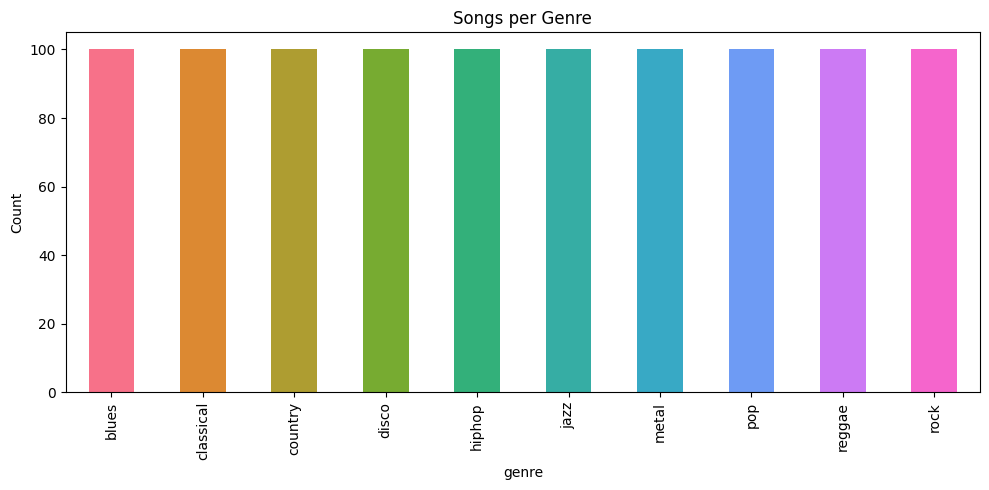

In [18]:
# Class distribution
fig, ax = plt.subplots(figsize=(10, 5))
stem_df.groupby('genre')['song'].nunique().plot(kind='bar', ax=ax, color=sns.color_palette("husl", 10))
ax.set_title("Songs per Genre"); ax.set_ylabel("Count"); plt.tight_layout()
wandb.log({"plots/class_distribution": wandb.Image(fig)}); plt.show()

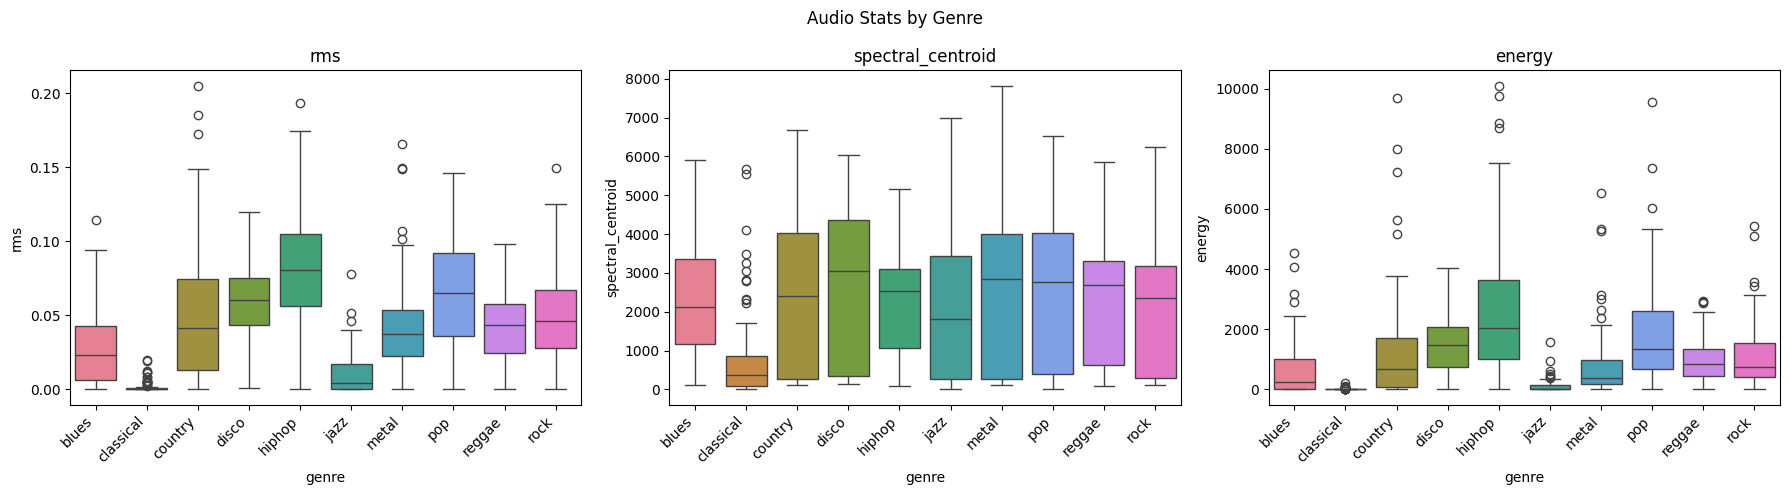

In [19]:
# Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['rms', 'spectral_centroid', 'energy']):
    sns.boxplot(data=stats_df, x='genre', y=col, ax=axes[i], palette='husl')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_title(col)
plt.suptitle("Audio Stats by Genre"); plt.tight_layout()
wandb.log({"plots/boxplots": wandb.Image(fig)}); plt.show()

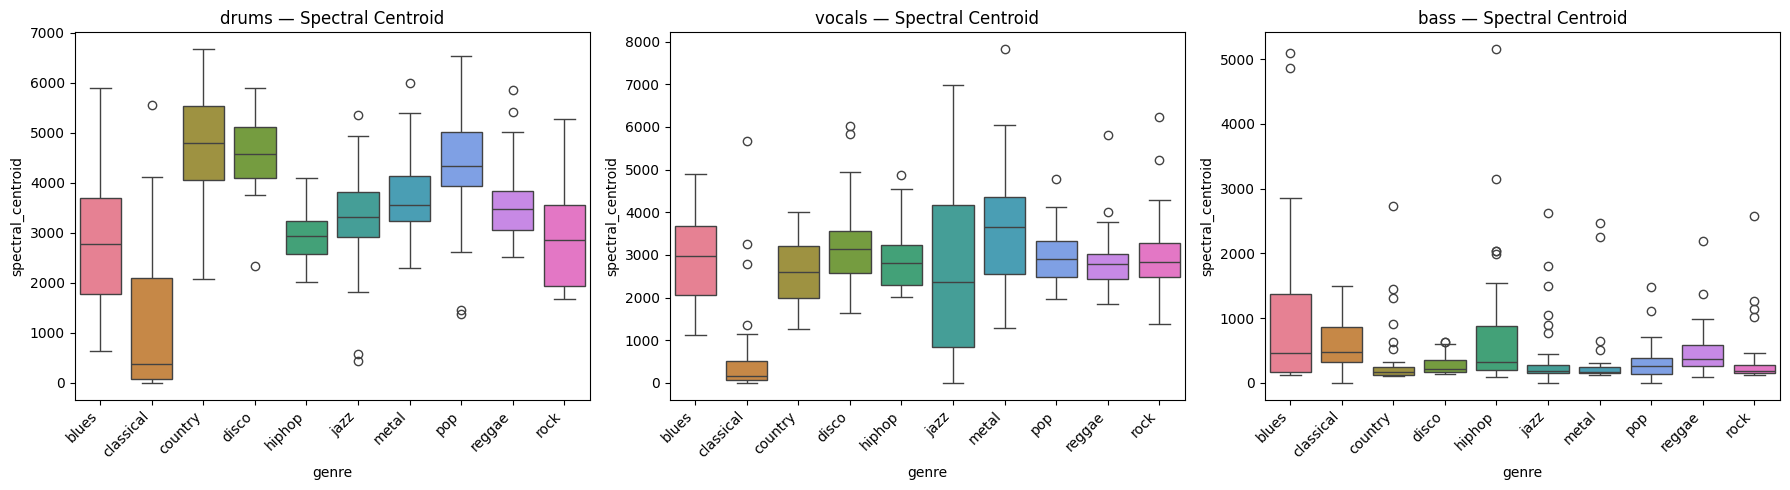

In [20]:
# Per-stem spectral centroid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, st in enumerate(['drums','vocals','bass']):
    sub = stats_df[stats_df['stem'] == st]
    sns.boxplot(data=sub, x='genre', y='spectral_centroid', ax=axes[i], palette='husl')
    axes[i].set_title(f'{st} — Spectral Centroid')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
wandb.log({"plots/stem_centroid": wandb.Image(fig)}); plt.show()

## 4. Mel Spectrograms

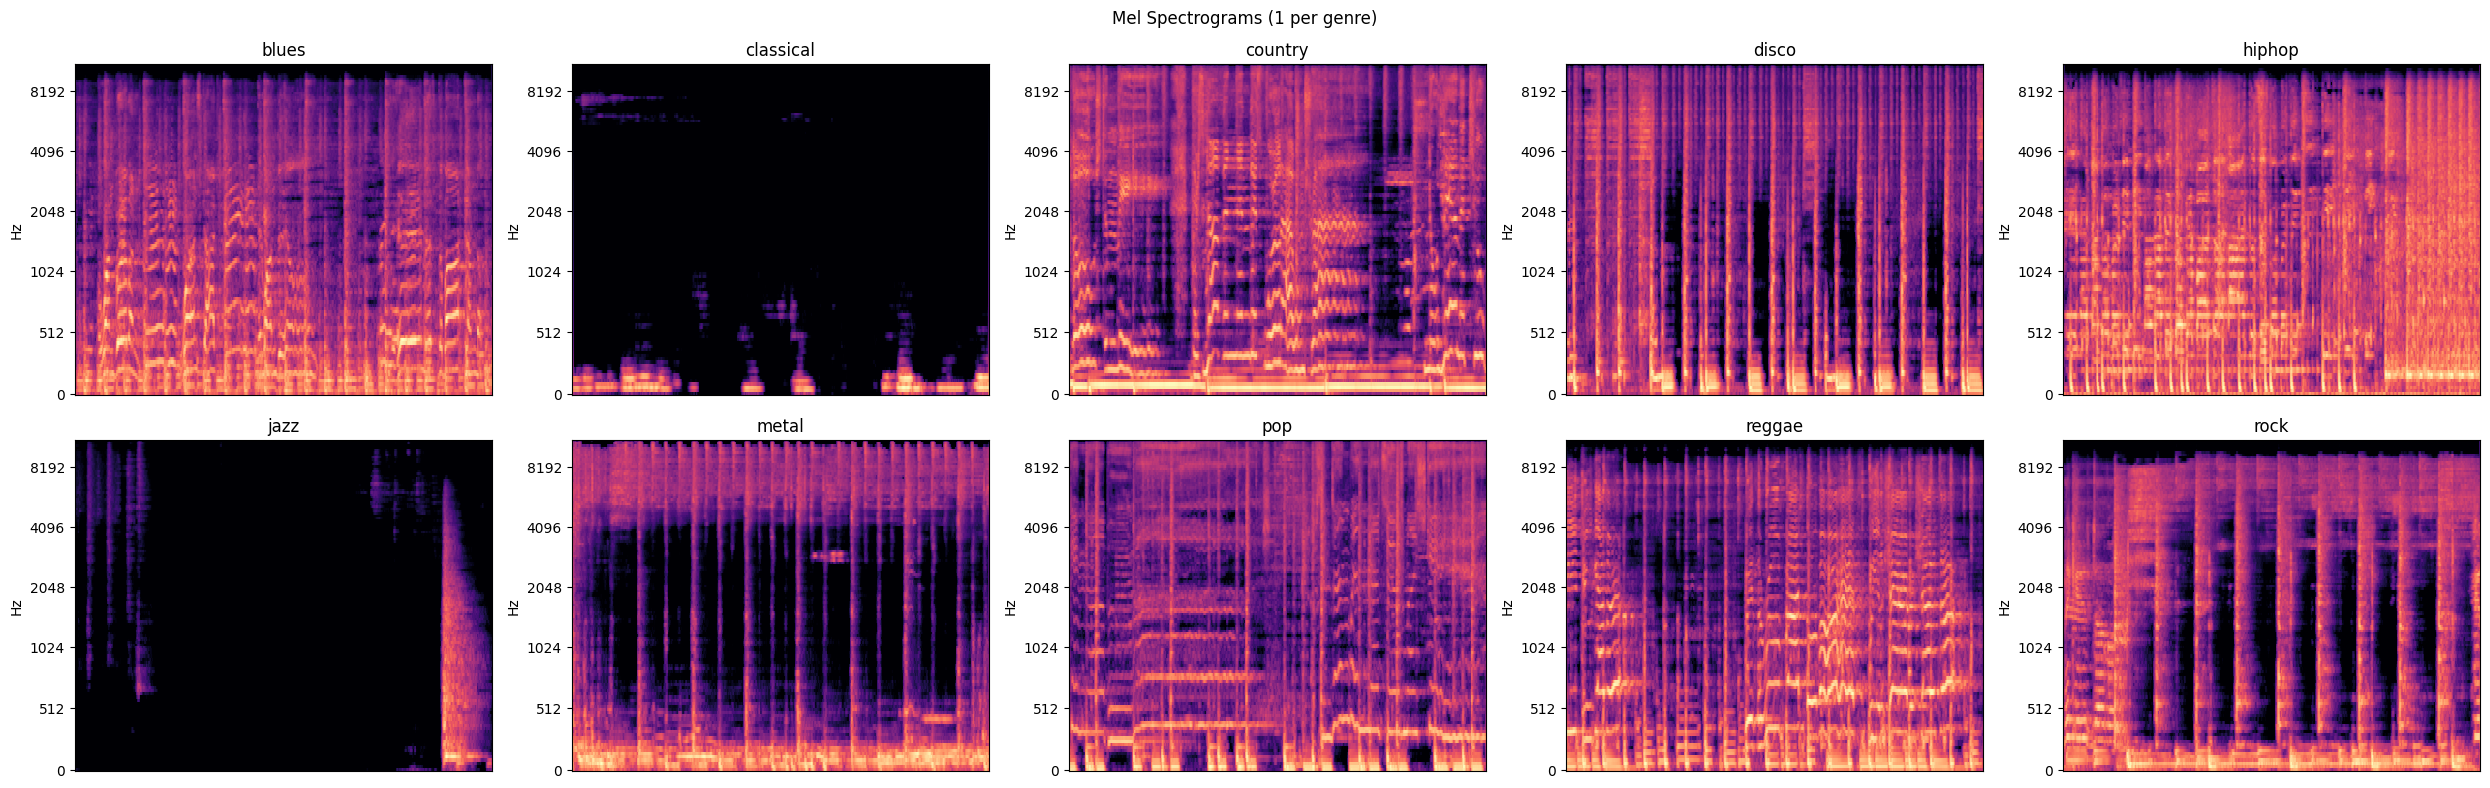

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(25, 8))
for idx, genre in enumerate(CFG.genres):
    ax = axes[idx//5][idx%5]
    gp = os.path.join(CFG.stems_dir, genre)
    song = sorted(os.listdir(gp))[0]
    # Mix available stems
    stems = []
    for st in ['drums','vocals','bass']:
        fp = os.path.join(gp, song, f"{st}.wav")
        if os.path.exists(fp):
            y, sr, _ = load_audio(fp, sr=CFG.sr, duration=CFG.duration)
            if y is not None: stems.append(y)
    if stems:
        mx_len = max(len(s) for s in stems)
        mix = np.zeros(mx_len)
        for s in stems: mix[:len(s)] += s
        mx = np.max(np.abs(mix))
        if mx > 0: mix /= mx
        S = librosa.feature.melspectrogram(y=mix, sr=CFG.sr, n_mels=CFG.n_mels, fmax=CFG.fmax)
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=CFG.sr, ax=ax, y_axis='mel', fmax=CFG.fmax)
    ax.set_title(genre)
plt.suptitle("Mel Spectrograms (1 per genre)"); plt.tight_layout()
wandb.log({"plots/mel_spectrograms": wandb.Image(fig)}); plt.show()

## 5. Train vs Test Distribution Shift
The test set contains noisy mashups — stems mixed across songs with noise added. This is the key challenge.

Test stats:   0%|          | 0/100 [00:00<?, ?it/s]

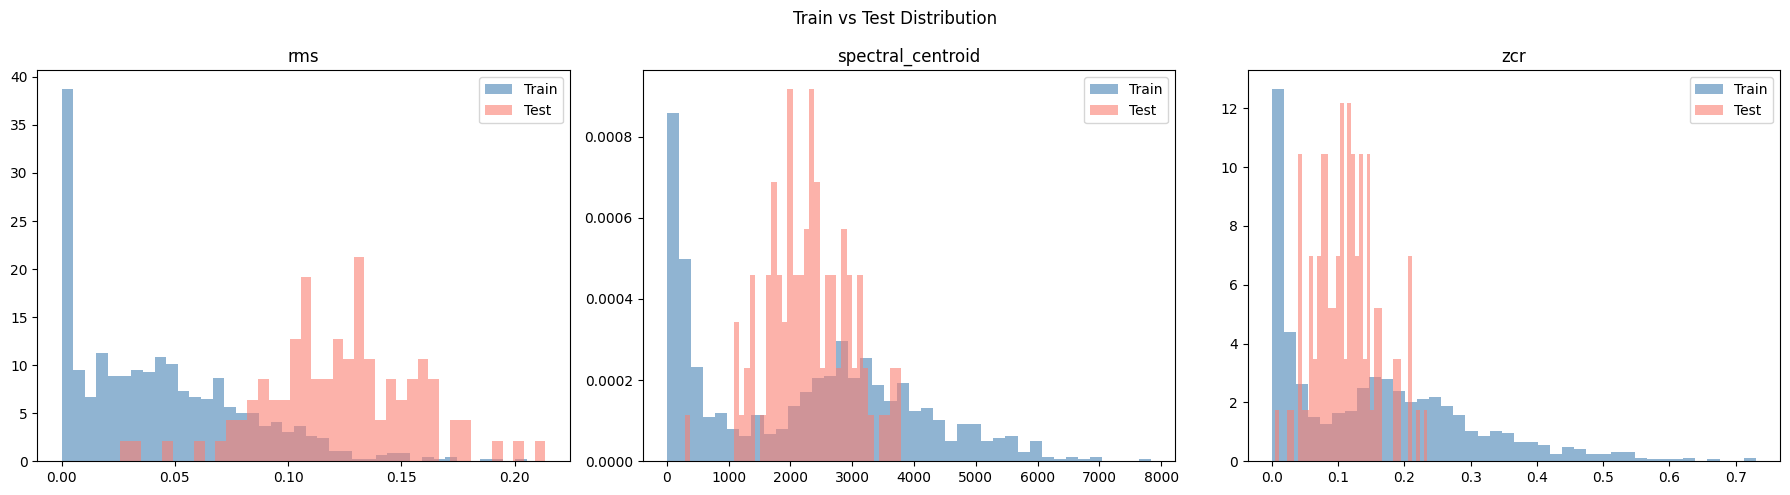

Key insight: test mashups are louder, denser, and noisier than individual training stems.
→ Augmentation must simulate this shift!


In [22]:
# Compute stats for test samples
test_sample = random.sample(test_files, min(100, len(test_files)))
test_stats = []
for tf in tqdm(test_sample, desc="Test stats"):
    y, sr, _ = load_audio(tf, sr=CFG.sr, duration=CFG.duration)
    if y is None: continue
    rms = librosa.feature.rms(y=y)[0]
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    test_stats.append(dict(rms=float(np.mean(rms)), spectral_centroid=float(np.mean(sc)),
                           zcr=float(np.mean(zcr))))
test_st_df = pd.DataFrame(test_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['rms','spectral_centroid','zcr']):
    axes[i].hist(stats_df[col].dropna(), bins=40, alpha=0.6, density=True, label='Train', color='steelblue')
    axes[i].hist(test_st_df[col].dropna(), bins=40, alpha=0.6, density=True, label='Test', color='salmon')
    axes[i].set_title(col); axes[i].legend()
plt.suptitle("Train vs Test Distribution"); plt.tight_layout()
wandb.log({"plots/train_vs_test": wandb.Image(fig)}); plt.show()
print("Key insight: test mashups are louder, denser, and noisier than individual training stems.")
print("→ Augmentation must simulate this shift!")

## 6. ESC-50 Noise Overview

ESC-50: 2000 clips across 50 categories

Top categories:
category
dog                40
chirping_birds     40
vacuum_cleaner     40
thunderstorm       40
door_wood_knock    40
can_opening        40
crow               40
clapping           40
fireworks          40
chainsaw           40
airplane           40
mouse_click        40
pouring_water      40
train              40
sheep              40
Name: count, dtype: int64


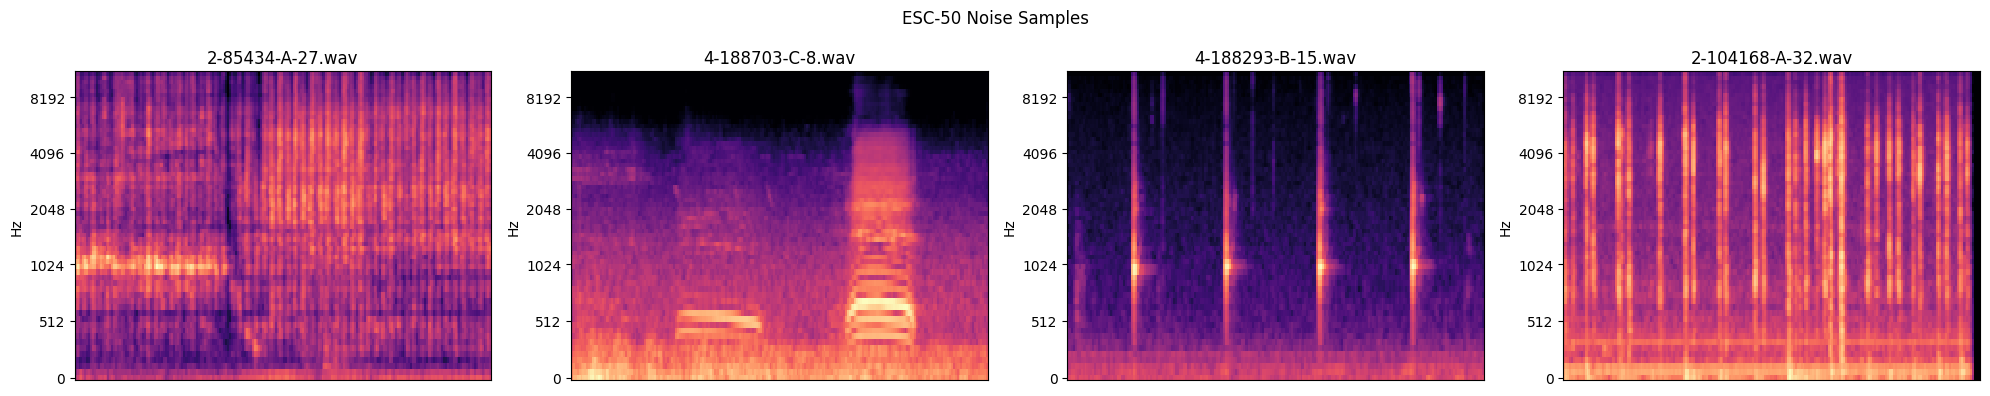

In [23]:
print(f"ESC-50: {len(esc_meta)} clips across {esc_meta['category'].nunique()} categories")
print("\nTop categories:")
print(esc_meta['category'].value_counts().head(15))

# Sample noise spectrograms
noise_files = glob.glob(os.path.join(CFG.noise_dir, "*.wav"))
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, nf in enumerate(random.sample(noise_files, 4)):
    y, sr, _ = load_audio(nf, sr=CFG.sr)
    if y is not None:
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, ax=axes[i], y_axis='mel')
        axes[i].set_title(os.path.basename(nf)[:20])
plt.suptitle("ESC-50 Noise Samples"); plt.tight_layout()
wandb.log({"plots/esc50_samples": wandb.Image(fig)}); plt.show()

## Summary
- **10 genres × 100 songs × 3 stems** (others stem missing for all songs)
- **Drums** carry the most genre signal, then vocals, bass is weakest
- **Classical/jazz** are very quiet — model must not rely on volume
- **Significant distribution shift** between clean stems (train) and noisy mashups (test)
- **ESC-50** provides 2000 noise clips for augmentation

In [24]:
wandb.log({"eda/status": "complete"})
wandb.finish()
print("01_eda complete.")

dataset/missing_stems,▁
dataset/songs_per_genre,▁
dataset/test_files,▁
dataset/missing_stems,1000
dataset/songs_per_genre,100
dataset/test_files,3020
eda/status,complete


01_eda complete.
